In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time

2025-02-04 13:40:56.959288: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-04 13:40:57.817562: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def create_new_version_dir(base_path):
    version = 1
    while True:
        version_dir = os.path.join(base_path, f'v{version}')
        if not os.path.exists(version_dir):
            os.makedirs(version_dir)
            print(f"Created new directory: {version_dir}")
            return version_dir
        version += 1

In [3]:
# Funktion zur Überwachung des Speicherverbrauchs
def check_memory_usage(threshold=90):
    memory = psutil.virtual_memory()
    if memory.percent > threshold:
        print(f"Warnung: Speicherverbrauch bei {memory.percent}%. Programm wird gestoppt.")
        raise MemoryError("Speicherverbrauch zu hoch")

In [4]:
# Load and Merge Data (Assuming MongoDB setup is correct)
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [5]:
# Preprocess Data

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

# Function to extract images and labels from DataFrame
def extract_images_from_df(df, example_user_id):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Example user ID
example_user_id = 'benutzername_1'

# Create DataFrames for each user
user_ids = merged_df['username'].unique()
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Sample data for the example user
user_df = user_dfs[example_user_id].sample(n=12000, random_state=42)

# Add negative examples and limit
negative_df = pd.concat([user_dfs[user_id] for user_id in user_ids if user_id != example_user_id])
negative_df = negative_df.sample(n=12000, random_state=42)

# Split into Train/Val/Test sets (70% Train, 20% Val, 10% Test)
train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

# Process image data
try:
    X_train, y_train = extract_images_from_df(train_df, example_user_id)
    X_val, y_val = extract_images_from_df(val_df, example_user_id)
    X_test, y_test = extract_images_from_df(test_df, example_user_id)
except Exception as e:
    print(f"Fehler bei der Bilddatenverarbeitung: {e}")

# Free up memory
gc.collect()

Lade Bilder: 100%|██████████| 2400/2400 [00:01<00:00, 1312.03it/s]


0

In [6]:
import os
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import numpy as np
from numba import cuda

# Function to get the latest version directory
def get_latest_version_dir(base_path):
    version = 1
    latest_version_dir = None
    while True:
        version_dir = os.path.join(base_path, f'v{version}')
        if not os.path.exists(version_dir):
            break
        latest_version_dir = version_dir
        version += 1
    return latest_version_dir

In [7]:
# Function to prepare images from the dataframe
def prepare_images(df, num_samples, example_user_id):
    images = []
    labels = []
    
    # Ensure at least 1000 samples from the example user
    example_user_samples = df[df['username'] == example_user_id].sample(n=1000, random_state=42)
    other_samples = df[df['username'] != example_user_id].sample(n=num_samples, random_state=42)
    
    sampled_df = pd.concat([example_user_samples, other_samples])
    
    for _, row in sampled_df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(row['username'])
    
    return np.array(images), np.array(labels)

In [8]:
# Test each model with 1000 samples from random users
num_samples = 1000
base_path = '/ssd'  # Ensure this is the correct base path
latest_version_dir = get_latest_version_dir(base_path)
model_names = ['create_model_1', 'create_model_2', 'create_model_3', 'create_model_4', 'create_model_5']
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000]
negative_sample_ratios = [0.5, 1, 2]

results = []
example_user_id = 'benutzername_1'  # Beispiel-Benutzer-ID
batch_size = 8  # Reduce batch size to avoid memory issues

In [9]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import load_model
from tqdm import tqdm
from PIL import Image
import io
import base64
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to clear GPU memory
def clear_gpu_memory():
    tf.keras.backend.clear_session()
    tf.compat.v1.reset_default_graph()

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to process image from base64 string
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to save results to a CSV file
def save_results_to_csv(results, filename="model_evaluation_results.csv", mode='w'):
    results_df = pd.DataFrame(results)
    results_df.to_csv(filename, index=False, mode=mode, header=(mode == 'w'))
    logging.info(f"Results saved to {filename}")

# Main function to evaluate models for a specific architecture
def evaluate_models_for_architecture(architecture, example_user_id='benutzername_1', num_samples=1000, batch_size=32, model_dir='/ssd/v1'):
    # Load data (implement your own data loading function)
    merged_df = load_data()  # This function must be defined
    print("Daten geladen")
    
    results = []
    actual_predicted_results = []
    
    # Filter models for the specified architecture
    model_files = [f for f in os.listdir(model_dir) if architecture in f]
    print(f"Modelle gefiltert: {model_files}")
    
    # Clear existing result files
    if os.path.exists(f"model_evaluation_results_{architecture}_samplesize_{num_samples}.csv"):
        os.remove(f"model_evaluation_results_{architecture}_samplesize_{num_samples}.csv")
    if os.path.exists(f"actual_predicted_results_{architecture}_samplesize_{num_samples}.csv"):
        os.remove(f"actual_predicted_results_{architecture}_samplesize_{num_samples}.csv")
    
    for model_file in tqdm(model_files, desc=f"Evaluating models for {architecture}"):
        if not model_file.endswith('.h5'):
            continue
        model_path = os.path.join(model_dir, model_file)
        
        try:
            model = load_model(model_path)
            logging.info(f"Loaded model {model_file}")
            print(f"Modell {model_file} geladen")
        except Exception as e:
            logging.error(f"Error loading model {model_file}: {e}")
            print(f"Fehler beim Laden des Modells {model_file}: {e}")
            continue
        
        user_ids = merged_df['username'].unique()
        
        # Ensure exactly num_samples samples from example_user_id
        example_user_df = merged_df[merged_df['username'] == example_user_id].sample(n=num_samples, random_state=42)
        X_test_example_user, y_test_example_user = prepare_images(example_user_df, example_user_id)
        
        y_pred_example_user = []
        y_prob_example_user = []
        current_batch_size = batch_size
        
        while True:
            try:
                with tf.device('/GPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                break
            except tf.errors.ResourceExhaustedError:
                logging.warning("GPU memory exhausted, switching to CPU")
                clear_gpu_memory()
                current_batch_size = max(1, current_batch_size // 2)
                if current_batch_size == 1:
                    with tf.device('/CPU:0'):
                        for i in range(0, len(X_test_example_user), current_batch_size):
                            batch = X_test_example_user[i:i + current_batch_size]
                            batch = tf.convert_to_tensor(batch)
                            y_pred_batch = model.predict(batch)
                            y_pred_example_user.extend(y_pred_batch)
                            y_prob_example_user.extend(y_pred_batch)
                    break
        
        y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
        
        # Ensure arrays have the same length
        if len(y_test_example_user) != len(y_pred_labels_example_user):
            logging.warning(f"Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
            print(f"Unterschiedliche Längen für y_test_example_user und y_pred_labels_example_user")
            continue
        
        results_df_example_user = pd.DataFrame({
            'Actual_User': y_test_example_user,
            'Predicted_User': y_pred_labels_example_user
        })
        
        metrics_example_user = evaluate_model(results_df_example_user['Actual_User'], results_df_example_user['Predicted_User'], np.array(y_prob_example_user).flatten())
        metrics_example_user['Model'] = model_file
        metrics_example_user['User'] = example_user_id
        results.append(metrics_example_user)
        
        for actual, predicted in zip(y_test_example_user, y_pred_labels_example_user):
            actual_predicted_results.append((model_file, example_user_id, actual, predicted))
        
        # Evaluate other users
        for user_id in tqdm(user_ids, desc=f"Evaluating users for model {model_file}"):
            if user_id == example_user_id:
                continue
            user_df = merged_df[merged_df['username'] == user_id].sample(n=num_samples, random_state=42)
            X_test_users, y_test_users = prepare_images(user_df, example_user_id)
            
            y_pred = []
            y_prob = []
            current_batch_size = batch_size
            
            while True:
                try:
                    with tf.device('/GPU:0'):
                        for i in range(0, len(X_test_users), current_batch_size):
                            batch = X_test_users[i:i + current_batch_size]
                            batch = tf.convert_to_tensor(batch)
                            y_pred_batch = model.predict(batch)
                            y_pred.extend(y_pred_batch)
                            y_prob.extend(y_pred_batch)
                    break
                except tf.errors.ResourceExhaustedError:
                    logging.warning("GPU memory exhausted, switching to CPU")
                    clear_gpu_memory()
                    current_batch_size = max(1, current_batch_size // 2)
                    if current_batch_size == 1:
                        with tf.device('/CPU:0'):
                            for i in range(0, len(X_test_users), current_batch_size):
                                batch = X_test_users[i:i + current_batch_size]
                                batch = tf.convert_to_tensor(batch)
                                y_pred_batch = model.predict(batch)
                                y_pred.extend(y_pred_batch)
                                y_prob.extend(y_pred_batch)
                        break
            
            y_pred_labels = [1 if pred > 0.5 else 0 for pred in np.array(y_pred).flatten()]
            
            # Ensure arrays have the same length
            if len(y_test_users) != len(y_pred_labels):
                logging.warning(f"Mismatched lengths for y_test_users and y_pred_labels for user {user_id}")
                print(f"Unterschiedliche Längen für y_test_users und y_pred_labels für Benutzer {user_id}")
                continue
            
            results_df = pd.DataFrame({
                'Actual_User': y_test_users,
                'Predicted_User': y_pred_labels
            })
            
            metrics = evaluate_model(results_df['Actual_User'], results_df['Predicted_User'], np.array(y_prob).flatten())
            metrics['Model'] = model_file
            metrics['User'] = user_id
            results.append(metrics)
            
            for actual, predicted in zip(y_test_users, y_pred_labels):
                actual_predicted_results.append((model_file, user_id, actual, predicted))
        
        # Save results after evaluating each model
        save_results_to_csv(results, filename=f"model_evaluation_results_{architecture}_samplesize_{num_samples}.csv", mode='a')
        save_results_to_csv(actual_predicted_results, filename=f"actual_predicted_results_{architecture}_samplesize_{num_samples}.csv", mode='a')
        print("Ergebnisse gespeichert")
        
        # Clear GPU memory after each model evaluation
        clear_gpu_memory()
        logging.info(f"Completed evaluation for model {model_file}")
        print(f"Bewertung für Modell {model_file} abgeschlossen")



In [ ]:
if __name__ == "__main__":
    architecture = 'create_model_1'  # Beispielarchitektur
    num_samples = 100  # Anzahl der Samples pro Benutzer
    evaluate_models_for_architecture(architecture, num_samples=num_samples)

In [ ]:
if __name__ == "__main__":
    architecture = 'create_model_2'  # Beispielarchitektur
    num_samples = 100  # Anzahl der Samples pro Benutzer
    evaluate_models_for_architecture(architecture, num_samples=num_samples)

In [ ]:
if __name__ == "__main__":
    architecture = 'create_model_3'  # Beispielarchitektur
    num_samples = 100  # Anzahl der Samples pro Benutzer
    evaluate_models_for_architecture(architecture, num_samples=num_samples)

In [ ]:
if __name__ == "__main__":
    architecture = 'create_model_4'  # Beispielarchitektur
    num_samples = 100  # Anzahl der Samples pro Benutzer
    evaluate_models_for_architecture(architecture, num_samples=num_samples)

In [ ]:
if __name__ == "__main__":
    architecture = 'create_model_5'  # Beispielarchitektur
    num_samples = 100  # Anzahl der Samples pro Benutzer
    evaluate_models_for_architecture(architecture, num_samples=num_samples)

In [ ]:
import os
import time
import tensorflow as tf
from tqdm import tqdm
import sys
import contextlib

# Unterdrücke TensorFlow-Ausgaben
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Farben für die Konsolenausgabe
class Colors:
    GREEN = '\033[92m'
    PURPLE = '\033[95m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    RESET = '\033[0m'

@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        try:
            sys.stdout = devnull
            sys.stderr = devnull
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

def evaluate_models_for_architecture(architecture, num_samples=1000, batch_size=32, model_dir='/ssd/v1'):
    # Load data (implement your own data loading function)
    merged_df = load_data()  # This function must be defined
    print(f"{Colors.GREEN}Daten geladen{Colors.RESET}")
    
    results = []
    actual_predicted_results = []
    
    # Filter models for the specified architecture
    model_files = [f for f in os.listdir(model_dir) if architecture in f]
    print(f"{Colors.GREEN}Modelle gefiltert: {model_files}{Colors.RESET}")
    
    # Clear existing result files
    result_filename = f"results/Cnn/model_evaluation_results_{architecture}_samplesize_{num_samples}.csv"
    actual_predicted_filename = f"results/Cnn/actual_predicted_results_{architecture}_samplesize_{num_samples}.csv"
    
    if os.path.exists(result_filename):
        print(f"{Colors.YELLOW}Ergebnisse für {architecture} mit {num_samples} Samples existieren bereits. Überspringen...{Colors.RESET}")
        return
    
    for model_file in tqdm(model_files, desc=f"Evaluating models for {architecture}"):
        if not model_file.endswith('.h5'):
            continue
        model_path = os.path.join(model_dir, model_file)
        
        try:
            model = load_model(model_path)
            logging.info(f"Loaded model {model_file}")
            print(f"{Colors.GREEN}Modell {model_file} geladen{Colors.RESET}")
        except Exception as e:
            logging.error(f"Error loading model {model_file}: {e}")
            print(f"{Colors.RED}Fehler beim Laden des Modells {model_file}: {e}{Colors.RESET}")
            continue
        
        user_ids = merged_df['username'].unique()
        
        # Ensure exactly num_samples samples from example_user_id
        example_user_df = merged_df[merged_df['username'] == example_user_id].sample(n=num_samples, random_state=42)
        X_test_example_user, y_test_example_user = prepare_images(example_user_df, example_user_id)
        
        y_pred_example_user = []
        y_prob_example_user = []
        current_batch_size = batch_size
        
        while True:
            try:
                with tf.device('/GPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                break
            except tf.errors.ResourceExhaustedError:
                logging.warning("GPU 0 memory exhausted, switching to GPU 1")
                clear_gpu_memory()
                try:
                    with tf.device('/GPU:1'):
                        for i in range(0, len(X_test_example_user), current_batch_size):
                            batch = X_test_example_user[i:i + current_batch_size]
                            batch = tf.convert_to_tensor(batch)
                            y_pred_batch = model.predict(batch)
                            y_pred_example_user.extend(y_pred_batch)
                            y_prob_example_user.extend(y_pred_batch)
                    break
                except tf.errors.ResourceExhaustedError:
                    logging.warning("GPU 1 memory exhausted, switching to CPU")
                    clear_gpu_memory()
                    current_batch_size = max(1, current_batch_size // 2)
                    if current_batch_size == 1:
                        with tf.device('/CPU:0'):
                            for i in range(0, len(X_test_example_user), current_batch_size):
                                batch = X_test_example_user[i:i + current_batch_size]
                                batch = tf.convert_to_tensor(batch)
                                y_pred_batch = model.predict(batch)
                                y_pred_example_user.extend(y_pred_batch)
                                y_prob_example_user.extend(y_pred_batch)
                        break
        
        y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
        
        # Ensure arrays have the same length
        if len(y_test_example_user) != len(y_pred_labels_example_user):
            logging.warning(f"Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
            print(f"{Colors.RED}Unterschiedliche Längen für y_test_example_user und y_pred_labels_example_user{Colors.RESET}")
            continue
        
        results_df_example_user = pd.DataFrame({
            'Actual_User': y_test_example_user,
            'Predicted_User': y_pred_labels_example_user
        })
        
        metrics_example_user = evaluate_model(results_df_example_user['Actual_User'], results_df_example_user['Predicted_User'], np.array(y_prob_example_user).flatten())
        metrics_example_user['Model'] = model_file
        metrics_example_user['User'] = example_user_id
        results.append(metrics_example_user)
        
        for actual, predicted in zip(y_test_example_user, y_pred_labels_example_user):
            actual_predicted_results.append((model_file, example_user_id, actual, predicted))
        
        # Evaluate other users
        for user_id in tqdm(user_ids, desc=f"Evaluating users for model {model_file}"):
            if user_id == example_user_id:
                continue
            user_df = merged_df[merged_df['username'] == user_id].sample(n=num_samples, random_state=42)
            X_test_users, y_test_users = prepare_images(user_df, example_user_id)
            
            y_pred = []
            y_prob = []
            current_batch_size = batch_size
            
            while True:
                try:
                    with tf.device('/GPU:0'):
                        for i in range(0, len(X_test_users), current_batch_size):
                            batch = X_test_users[i:i + current_batch_size]
                            batch = tf.convert_to_tensor(batch)
                            y_pred_batch = model.predict(batch)
                            y_pred.extend(y_pred_batch)
                            y_prob.extend(y_pred_batch)
                    break
                except tf.errors.ResourceExhaustedError:
                    logging.warning("GPU 0 memory exhausted, switching to GPU 1")
                    clear_gpu_memory()
                    try:
                        with tf.device('/GPU:1'):
                            for i in range(0, len(X_test_users), current_batch_size):
                                batch = X_test_users[i:i + current_batch_size]
                                batch = tf.convert_to_tensor(batch)
                                y_pred_batch = model.predict(batch)
                                y_pred.extend(y_pred_batch)
                                y_prob.extend(y_pred_batch)
                        break
                    except tf.errors.ResourceExhaustedError:
                        logging.warning("GPU 1 memory exhausted, switching to CPU")
                        clear_gpu_memory()
                        current_batch_size = max(1, current_batch_size // 2)
                        if current_batch_size == 1:
                            with tf.device('/CPU:0'):
                                for i in range(0, len(X_test_users), current_batch_size):
                                    batch = X_test_users[i:i + current_batch_size]
                                    batch = tf.convert_to_tensor(batch)
                                    y_pred_batch = model.predict(batch)
                                    y_pred.extend(y_pred_batch)
                                    y_prob.extend(y_pred_batch)
                            break
            
            y_pred_labels = [1 if pred > 0.5 else 0 for pred in np.array(y_pred).flatten()]
            
            # Ensure arrays have the same length
            if len(y_test_users) != len(y_pred_labels):
                logging.warning(f"Mismatched lengths for y_test_users and y_pred_labels for user {user_id}")
                print(f"{Colors.RED}Unterschiedliche Längen für y_test_users und y_pred_labels für Benutzer {user_id}{Colors.RESET}")
                continue
            
            results_df = pd.DataFrame({
                'Actual_User': y_test_users,
                'Predicted_User': y_pred_labels
            })
            
            metrics = evaluate_model(results_df['Actual_User'], results_df['Predicted_User'], np.array(y_prob).flatten())
            metrics['Model'] = model_file
            metrics['User'] = user_id
            results.append(metrics)
            
            for actual, predicted in zip(y_test_users, y_pred_labels):
                actual_predicted_results.append((model_file, user_id, actual, predicted))
        
        # Save results after evaluating each model
        save_results_to_csv(results, filename=result_filename, mode='a')
        save_results_to_csv(actual_predicted_results, filename=actual_predicted_filename, mode='a')
        print(f"{Colors.GREEN}Ergebnisse gespeichert{Colors.RESET}")
        
        # Clear GPU memory after each model evaluation
        clear_gpu_memory()
        logging.info(f"Completed evaluation for model {model_file}")
        print(f"{Colors.GREEN}Bewertung für Modell {model_file} abgeschlossen{Colors.RESET}")

if __name__ == "__main__":
    architectures = [f'create_model_{i}' for i in range(1, 6)]  # Architekturen von 1 bis 5
    sample_sizes = [1000, 800, 600, 400, 200]  # Verschiedene Sample-Größen

    total_tasks = len(architectures) * len(sample_sizes)
    task_counter = 0

    for architecture in architectures:
        for num_samples in sample_sizes:
            result_filename = f"results/Cnn/model_evaluation_results_{architecture}_samplesize_{num_samples}.csv"
            if os.path.exists(result_filename):
                print(f"{Colors.YELLOW}Ergebnisse für {architecture} mit {num_samples} Samples existieren bereits. Überspringen...{Colors.RESET}")
                continue
            
            task_counter += 1
            try:
                start_time = time.time()
                print(f"{Colors.GREEN}Evaluating models for architecture {architecture} with {num_samples} samples{Colors.RESET}")
                with suppress_stdout_stderr():
                    evaluate_models_for_architecture(architecture, num_samples=num_samples)
            except tf.errors.ResourceExhaustedError:
                print(f"{Colors.RED}Resource exhausted for {num_samples} samples, clearing GPU memory and retrying with smaller batch size{Colors.RESET}")
                clear_gpu_memory()
                with suppress_stdout_stderr():
                    evaluate_models_for_architecture(architecture, num_samples=num_samples)
            except Exception as e:
                print(f"{Colors.RED}An error occurred: {e}{Colors.RESET}")
                clear_gpu_memory()
            finally:
                elapsed_time = time.time() - start_time
                remaining_tasks = total_tasks - task_counter
                estimated_time_remaining = (elapsed_time / task_counter) * remaining_tasks
                tqdm.write(f"{Colors.GREEN}Progress: {task_counter}/{total_tasks} ({(task_counter / total_tasks) * 100:.2f}%) - Estimated time remaining: {estimated_time_remaining:.2f} seconds{Colors.RESET}")
                tqdm.write(f"{Colors.GREEN}Task {task_counter} completed in {elapsed_time:.2f} seconds{Colors.RESET}")
                tqdm.write(f"{Colors.GREEN}Clearing GPU memory{Colors.RESET}")
                clear_gpu_memory()

    print(f"{Colors.GREEN}All tasks completed.{Colors.RESET}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and combine results
def load_and_combine_results(sample_sizes):
    all_results = []
    expected_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Model', 'User']
    
    for sample_size in sample_sizes:
        for i in range(1, 6):
            file_path = f"results/Cnn/model_evaluation_results_create_model_{i}_samplesize_{sample_size}.csv"
            print(f"Überprüfe Datei: {file_path}")  # Debugging-Information
            if os.path.exists(file_path):
                results_df = pd.read_csv(file_path)
                logging.info(f"Loaded results for architecture {i} with sample size {sample_size}: {results_df.shape}")
                logging.debug(f"Results for architecture {i} with sample size {sample_size}:\n{results_df.head()}")
                
                # Check and rename columns if necessary
                if results_df.shape[1] == len(expected_columns):
                    results_df.columns = expected_columns
                else:
                    logging.warning(f"Unexpected columns in file {file_path}: {results_df.columns.tolist()}")
                
                # Add sample size as a new column
                results_df['Sample_Size'] = sample_size
                
                all_results.append(results_df)
            else:
                logging.warning(f"File {file_path} does not exist and will be skipped.")
    
    if all_results:
        combined_results_df = pd.concat(all_results, ignore_index=True)
        logging.info(f"Combined results shape: {combined_results_df.shape}")
        logging.debug(f"Combined results columns: {combined_results_df.columns.tolist()}")
        logging.debug(f"Combined results:\n{combined_results_df.head()}")
        return combined_results_df
    else:
        logging.error("No result files found.")
        print("No result files found.")  # Debugging-Information
        return pd.DataFrame()  # Return an empty DataFrame if no files are found

# Function to shorten model names
def shorten_model_names(df):
    df['Model'] = df['Model'].apply(lambda x: '_'.join(x.split('_')[2:5]))
    return df

# Function to sort models
def sort_models(df):
    df['Model_Sort'] = df['Model'].apply(lambda x: (int(x.split('_')[0]), int(x.split('_')[2])))
    df = df.sort_values(by='Model_Sort').drop(columns='Model_Sort')
    return df

# Function to plot metrics
def plot_metrics(combined_results_df, metrics):
    for metric in metrics:
        if metric in combined_results_df.columns:
            plt.figure(figsize=(14, 10))
            sns.lineplot(data=combined_results_df, x='Model', y=metric, hue='Sample_Size', marker='o')
            plt.title(f"Vergleich der Modell-Leistungen: {metric}", fontsize=18)
            plt.xlabel("Modelle", fontsize=16)
            plt.ylabel(metric, fontsize=16)
            plt.xticks(rotation=45, fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            logging.debug(f"Plotted {metric} for models")
        else:
            logging.warning(f"Metric {metric} does not exist in the combined results")

# Function to plot boxplots
def plot_boxplots(combined_results_df, metrics):
    for metric in metrics:
        if metric in combined_results_df.columns:
            plt.figure(figsize=(12, 8))
            sns.boxplot(x='Model', y=metric, hue='Sample_Size', data=combined_results_df)
            plt.title(f"Verteilung von {metric} über verschiedene Modelle", fontsize=18)
            plt.xlabel("Modelle", fontsize=16)
            plt.ylabel(metric, fontsize=16)
            plt.xticks(rotation=45, fontsize=12)
            plt.yticks(fontsize=12)
            plt.tight_layout()
            plt.show()
            logging.debug(f"Boxplot for {metric}")
        else:
            logging.warning(f"Metric {metric} does not exist in the combined results")

# Function to plot metrics by architecture
def plot_metrics_by_architecture(combined_results_df, metrics):
    architectures = combined_results_df['Model'].apply(lambda x: x.split('_')[0]).unique()
    for architecture in architectures:
        arch_df = combined_results_df[combined_results_df['Model'].str.startswith(architecture)]
        for metric in metrics:
            if metric in arch_df.columns:
                plt.figure(figsize=(14, 10))
                sns.lineplot(data=arch_df, x='Model', y=metric, hue='Sample_Size', marker='o')
                plt.title(f"Vergleich der Modell-Leistungen für {architecture}: {metric}", fontsize=18)
                plt.xlabel("Modelle", fontsize=16)
                plt.ylabel(metric, fontsize=16)
                plt.xticks(rotation=45, fontsize=12)
                plt.yticks(fontsize=12)
                plt.grid(True)
                plt.tight_layout()
                plt.show()
                logging.debug(f"Plotted {metric} for {architecture} models")
            else:
                logging.warning(f"Metric {metric} does not exist in the combined results for {architecture}")

# Function to summarize best models
def summarize_best_models(combined_results_df):
    best_models = {}
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    for metric in metrics:
        if metric in combined_results_df.columns:
            best_model = combined_results_df.loc[combined_results_df[metric].idxmax(), 'Model']
            best_models[metric] = best_model
            logging.info(f"Model with the best {metric}: {best_model}")
        else:
            logging.warning(f"Metric {metric} does not exist in the combined results")

    # Print summary of best models
    print("\nZusammenfassung der besten Modelle basierend auf verschiedenen Metriken:")
    for metric, model in best_models.items():
        print(f"Das Modell mit dem besten {metric} ist: {model}")

    # Recommendation based on results
    if len(set(best_models.values())) == 1:
        best_model = next(iter(best_models.values()))
        logging.info("Recommendation: The consistently best model is suitable for deployment.")
        print(f"Empfehlung: Das konsistent beste Modell ({best_model}) ist geeignet für den Einsatz.")
    else:
        logging.info("Recommendation: Different models perform better on different metrics. Choose based on specific requirements.")
        print("Empfehlung: Unterschiedliche Modelle performen unterschiedlich gut je nach Metrik. Wähle basierend auf spezifischen Anforderungen.")

# Function to save results to CSV
def save_results_to_csv(df, filename):
    df.to_csv(filename, index=False)
    logging.info(f"Results saved to {filename}")

# Function to evaluate models and plot confusion matrices
def evaluate_models(y_true, y_pred, y_prob, model_name):
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    class_report = classification_report(y_true, y_pred)
    print(f"Classification Report for {model_name}:\n", class_report)

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {model_name}')
    plt.legend(loc="lower right")
    plt.show()

    # Accuracy, Precision, Recall, F1 Score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy for {model_name}: {accuracy:.2f}")
    print(f"Precision for {model_name}: {precision:.2f}")
    print(f"Recall for {model_name}: {recall:.2f}")
    print(f"F1 Score for {model_name}: {f1:.2f}")

# Main function to perform analysis
def main(sample_sizes, evaluate_all=False):
    if evaluate_all:
        sample_sizes = [1000, 800, 600, 400, 200]  # Alle Sample-Größen

    combined_results_df = load_and_combine_results(sample_sizes)
    
    if combined_results_df.empty:
        logging.error("No data to analyze.")
        print("No data to analyze.")
        return
    
    # Shorten model names
    combined_results_df = shorten_model_names(combined_results_df)
    
    # Sort models
    combined_results_df = sort_models(combined_results_df)
    
    # Check if 'ROC AUC' column exists and fill NaN values with 0
    if 'ROC AUC' in combined_results_df.columns:
        combined_results_df['ROC AUC'].fillna(0, inplace=True)

    # Display results
    logging.info("Summary of model performances:")
    print("Zusammenfassung der Modell-Leistungen:")
    print(combined_results_df.head())  # Display the first few rows of the combined results

    # Identify best models
    summarize_best_models(combined_results_df)

    # Visualize metrics for all models
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    plot_metrics(combined_results_df, metrics)

    # Boxplots for each metric to illustrate distribution
    plot_boxplots(combined_results_df, metrics)

    # Visualize metrics by architecture
    plot_metrics_by_architecture(combined_results_df, metrics)

    # Save results to CSV
    save_results_to_csv(combined_results_df, "combined_model_evaluation_results.csv")

    # Example evaluation for a specific model (replace with actual data)
    y_true = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
    y_pred = np.array([0, 1, 0, 0, 0, 1, 0, 1, 1, 1])
    y_prob = np.array([0.1, 0.9, 0.2, 0.4, 0.3, 0.8, 0.1, 0.7, 0.6, 0.9])
    evaluate_models(y_true, y_pred, y_prob, "Example Model")

if __name__ == "__main__":
    evaluate_all = True  # Set to True to evaluate all sample sizes
    sample_sizes = [1000]  # Beispiel-Sample-Größen, wenn evaluate_all False ist
    main(sample_sizes, evaluate_all)

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to evaluate a specific model
def evaluate_specific_model(model_path, example_user_id='benutzername_1', num_samples=100000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data with at least 10% from example_user_id
    user_1_samples = int(num_samples * 0.1)
    other_samples = num_samples - user_1_samples
    
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=user_1_samples, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=other_samples, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return None
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    total_batches = len(X_test_example_user) // current_batch_size
    start_time = time.time()
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in tqdm(range(0, len(X_test_example_user), current_batch_size), desc="Predicting", unit="batch"):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
                    
                    elapsed_time = time.time() - start_time
                    remaining_batches = total_batches - (i // current_batch_size)
                    estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                    logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in tqdm(range(0, len(X_test_example_user), current_batch_size), desc="Predicting", unit="batch"):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                        
                        elapsed_time = time.time() - start_time
                        remaining_batches = total_batches - (i // current_batch_size)
                        estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                        logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return None
    
    # Evaluate model
    metrics = evaluate_model(y_test_example_user, y_pred_labels_example_user, np.array(y_prob_example_user).flatten())
    metrics['y_pred_labels_example_user'] = y_pred_labels_example_user
    metrics['y_test_example_user'] = y_test_example_user
    logging.info(f"Evaluation metrics: {metrics}")
    
    return metrics

# Function to display confusion matrix for the model
def display_confusion_matrix(model_path, example_user_id='benutzername_1', num_samples=100000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data with at least 10% from example_user_id
    user_1_samples = int(num_samples * 0.1)
    other_samples = num_samples - user_1_samples
    
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=user_1_samples, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=other_samples, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return None
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    total_batches = len(X_test_example_user) // current_batch_size
    start_time = time.time()
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in tqdm(range(0, len(X_test_example_user), current_batch_size), desc="Predicting", unit="batch"):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
                    
                    elapsed_time = time.time() - start_time
                    remaining_batches = total_batches - (i // current_batch_size)
                    estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                    logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in tqdm(range(0, len(X_test_example_user), current_batch_size), desc="Predicting", unit="batch"):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                        
                        elapsed_time = time.time() - start_time
                        remaining_batches = total_batches - (i // current_batch_size)
                        estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                        logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return None
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_example_user, y_pred_labels_example_user)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_path}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Example usage
if __name__ == "__main__":
    model_path = '/ssd/v1/Architektur_1_200_samples_negative_ratio_2.h5'  # Replace with the path to your model
    display_confusion_matrix(model_path)

2025-01-25 11:46:53.345798: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-25 11:46:54.200205: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-01-25 11:48:47,569 - INFO - Data loaded
2025-01-25 11:48:52.307838: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-25 11:48:52.336261: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must b

1/1 [==============================] - 0s 421ms/step


2025-01-25 11:48:55.675356: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2025-01-25 11:48:55.843827: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - 0s 89ms/step


2025-01-25 11:49:03,789 - INFO - Evaluation metrics: {'Accuracy': 0.9303333333333333, 'Precision': 0.8383233532934131, 'Recall': 0.98, 'F1 Score': 0.9036422314430613, 'ROC AUC': 0.979398}


Evaluation Metrics:
Accuracy: 0.9303
Precision: 0.8383
Recall: 0.9800
F1 Score: 0.9036
ROC AUC: 0.9794


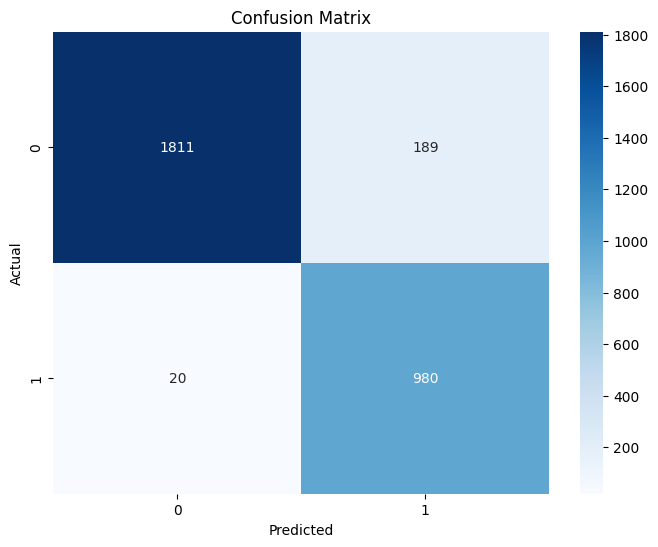

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      2000
           1       0.84      0.98      0.90      1000

    accuracy                           0.93      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.94      0.93      0.93      3000



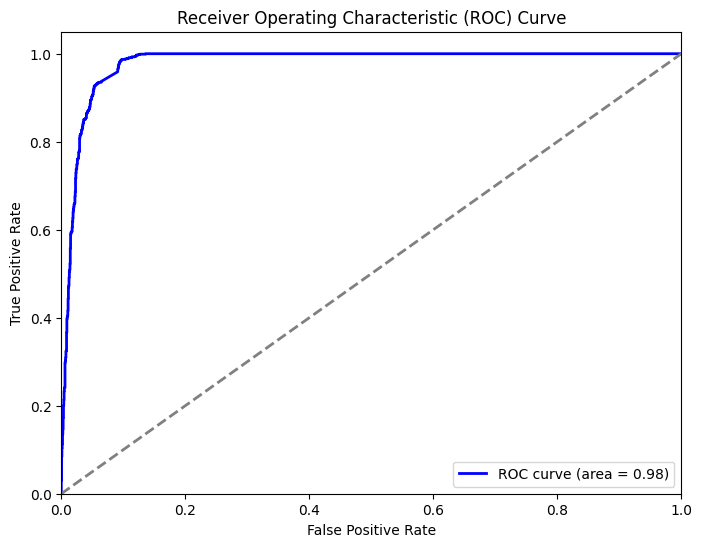

: 

: 

: 

: 

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to evaluate a specific model
def evaluate_specific_model(model_path, example_user_id='benutzername_1', num_samples=2000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=1000, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=2000, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in range(0, len(X_test_example_user), current_batch_size):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return
    
    # Evaluate model
    metrics = evaluate_model(y_test_example_user, y_pred_labels_example_user, np.array(y_prob_example_user).flatten())
    logging.info(f"Evaluation metrics: {metrics}")
    
    # Print results
    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: None")
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_example_user, y_pred_labels_example_user)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    class_report = classification_report(y_test_example_user, y_pred_labels_example_user)
    print("Classification Report:\n", class_report)

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_test_example_user, y_prob_example_user)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Example usage
if __name__ == "__main__":
    model_path = '/ssd/v1/create_model_1_samplesize_2000_negratio_2.h5'
    evaluate_specific_model(model_path)

2025-01-23 10:24:13.422192: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-23 10:24:14.006875: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-01-23 10:24:53,791 - INFO - Data loaded
2025-01-23 10:24:58.450659: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 10:24:58.478536: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must b

1/1 [==============================] - 0s 94ms/step


2025-01-23 10:25:10,745 - INFO - Evaluation metrics: {'Accuracy': 0.9303333333333333, 'Precision': 0.8383233532934131, 'Recall': 0.98, 'F1 Score': 0.9036422314430613, 'ROC AUC': 0.979398}


Evaluation Metrics:
Accuracy: 0.9303
Precision: 0.8383
Recall: 0.9800
F1 Score: 0.9036
ROC AUC: 0.9794


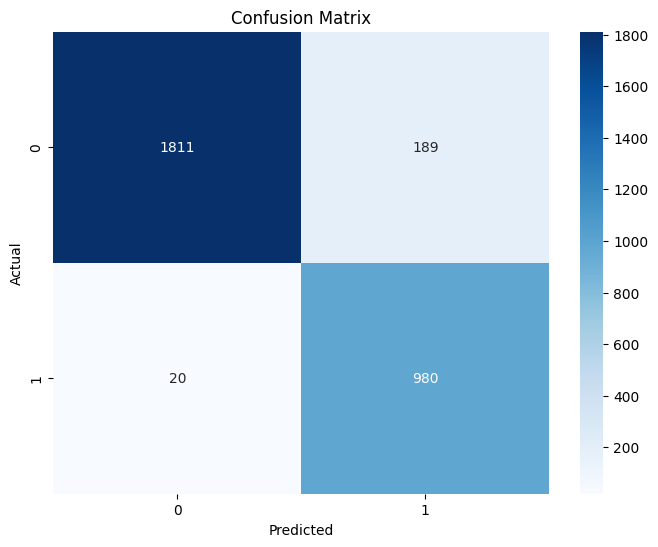

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      2000
           1       0.84      0.98      0.90      1000

    accuracy                           0.93      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.94      0.93      0.93      3000



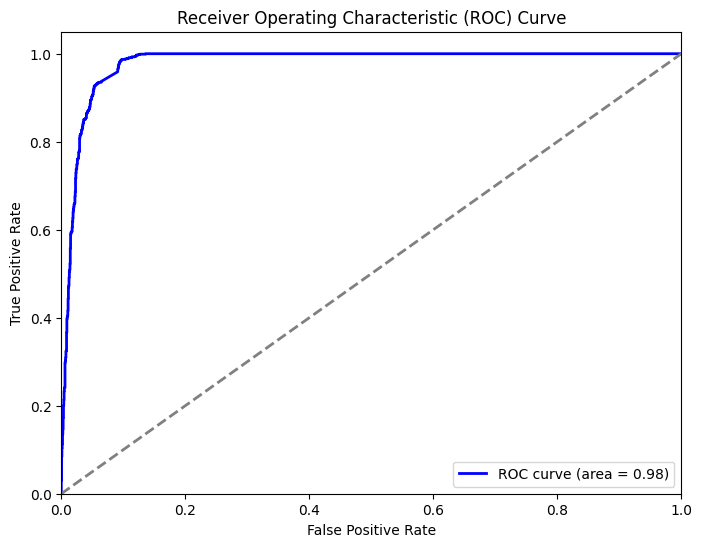

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to evaluate a specific model
def evaluate_specific_model(model_path, example_user_id='benutzername_1', num_samples=2000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=1000, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=2000, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in range(0, len(X_test_example_user), current_batch_size):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return
    
    # Evaluate model
    metrics = evaluate_model(y_test_example_user, y_pred_labels_example_user, np.array(y_prob_example_user).flatten())
    logging.info(f"Evaluation metrics: {metrics}")
    
    # Print results
    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: None")
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_example_user, y_pred_labels_example_user)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    class_report = classification_report(y_test_example_user, y_pred_labels_example_user)
    print("Classification Report:\n", class_report)

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_test_example_user, y_prob_example_user)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Example usage
if __name__ == "__main__":
    model_path = '/ssd/v1/create_model_1_samplesize_2000_negratio_2.h5'
    evaluate_specific_model(model_path)

2025-01-16 14:45:30,074 - INFO - Data loaded
2025-01-16 14:45:34,984 - INFO - Loaded model from /ssd/v1/create_model_3_samplesize_1000_negratio_2.h5


1/1 [==============================] - 0s 107ms/step


2025-01-16 14:45:43,961 - INFO - Evaluation metrics: {'Accuracy': 0.6666666666666666, 'Precision': 0.0, 'Recall': 0.0, 'F1 Score': 0.0, 'ROC AUC': 0.5}


Evaluation Metrics:
Accuracy: 0.6667
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.5000


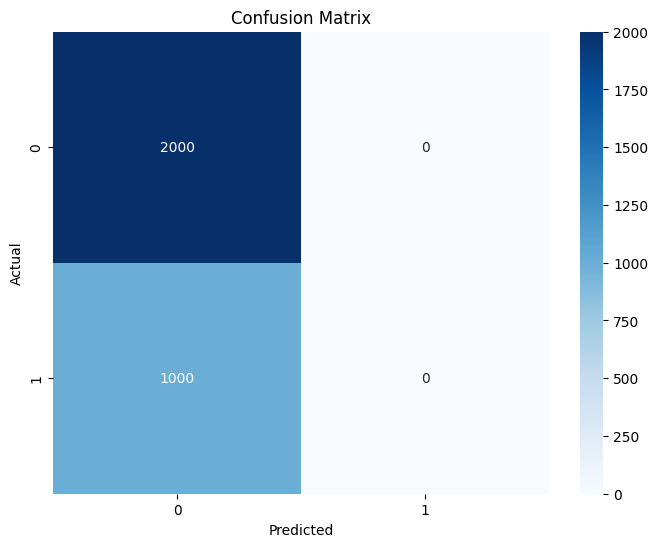

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80      2000
           1       0.00      0.00      0.00      1000

    accuracy                           0.67      3000
   macro avg       0.33      0.50      0.40      3000
weighted avg       0.44      0.67      0.53      3000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


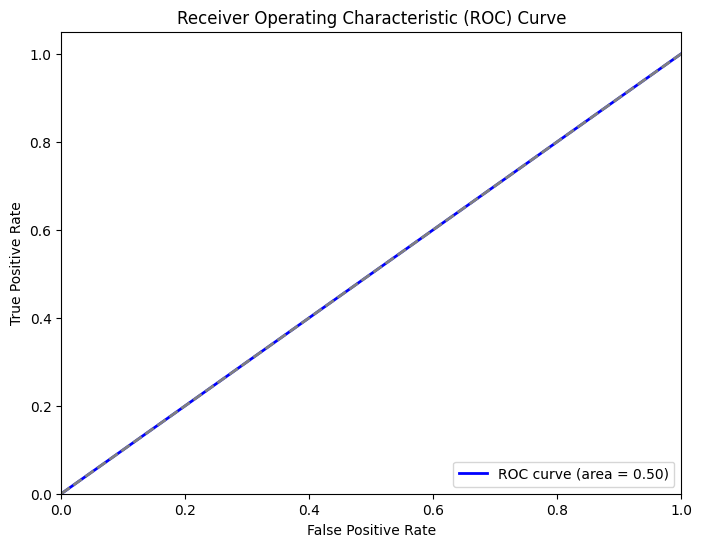

In [4]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to evaluate a specific model
def evaluate_specific_model(model_path, example_user_id='benutzername_1', num_samples=2000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=1000, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=2000, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in range(0, len(X_test_example_user), current_batch_size):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return
    
    # Evaluate model
    metrics = evaluate_model(y_test_example_user, y_pred_labels_example_user, np.array(y_prob_example_user).flatten())
    logging.info(f"Evaluation metrics: {metrics}")
    
    # Print results
    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: None")
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_example_user, y_pred_labels_example_user)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    class_report = classification_report(y_test_example_user, y_pred_labels_example_user)
    print("Classification Report:\n", class_report)

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_test_example_user, y_prob_example_user)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Example usage
if __name__ == "__main__":
    model_path = '/ssd/v1/create_model_3_samplesize_1000_negratio_2.h5'
    evaluate_specific_model(model_path)

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
import tensorflow as tf
from numba import cuda
import time
import logging
import random

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname=s - %(message=s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to evaluate the model
def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None,
    }
    return metrics

# Function to evaluate a specific model
def evaluate_specific_model(model_path, example_user_id='benutzername_1', num_samples=5000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data with at least 10% from example_user_id
    user_1_samples = int(num_samples * 0.1)
    other_samples = num_samples - user_1_samples
    
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=user_1_samples, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=other_samples, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return None
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    total_batches = len(X_test_example_user) // current_batch_size
    start_time = time.time()
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in range(0, len(X_test_example_user), current_batch_size):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
                    
                    elapsed_time = time.time() - start_time
                    remaining_batches = total_batches - (i // current_batch_size)
                    estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                    logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                        
                        elapsed_time = time.time() - start_time
                        remaining_batches = total_batches - (i // current_batch_size)
                        estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                        logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return None
    
    # Evaluate model
    metrics = evaluate_model(y_test_example_user, y_pred_labels_example_user, np.array(y_prob_example_user).flatten())
    metrics['y_pred_labels_example_user'] = y_pred_labels_example_user
    metrics['y_test_example_user'] = y_test_example_user
    logging.info(f"Evaluation metrics: {metrics}")
    
    return metrics

# Function to display confusion matrix for the model
def display_confusion_matrix(model_path, example_user_id='benutzername_1', num_samples=5000, batch_size=32):
    # Load data
    merged_df = load_data()
    logging.info("Data loaded")
    
    # Prepare test data with at least 10% from example_user_id
    user_1_samples = int(num_samples * 0.1)
    other_samples = num_samples - user_1_samples
    
    user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=user_1_samples, random_state=42)
    other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=other_samples, random_state=42)
    combined_df = pd.concat([user_1_df, other_users_df])
    X_test_example_user, y_test_example_user = prepare_images(combined_df, example_user_id)
    
    # Load model
    try:
        model = load_model(model_path)
        logging.info(f"Loaded model from {model_path}")
    except Exception as e:
        logging.error(f"Error loading model from {model_path}: {e}")
        return None
    
    # Predict
    y_pred_example_user = []
    y_prob_example_user = []
    current_batch_size = batch_size
    total_batches = len(X_test_example_user) // current_batch_size
    start_time = time.time()
    
    while True:
        try:
            with tf.device('/GPU:0'):
                for i in range(0, len(X_test_example_user), current_batch_size):
                    batch = X_test_example_user[i:i + current_batch_size]
                    batch = tf.convert_to_tensor(batch)
                    y_pred_batch = model.predict(batch)
                    y_pred_example_user.extend(y_pred_batch)
                    y_prob_example_user.extend(y_pred_batch)
                    
                    elapsed_time = time.time() - start_time
                    remaining_batches = total_batches - (i // current_batch_size)
                    estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                    logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
            break
        except tf.errors.ResourceExhaustedError:
            logging.warning("GPU memory exhausted, switching to CPU")
            clear_gpu_memory()
            current_batch_size = max(1, current_batch_size // 2)
            if current_batch_size == 1:
                with tf.device('/CPU:0'):
                    for i in range(0, len(X_test_example_user), current_batch_size):
                        batch = X_test_example_user[i:i + current_batch_size]
                        batch = tf.convert_to_tensor(batch)
                        y_pred_batch = model.predict(batch)
                        y_pred_example_user.extend(y_pred_batch)
                        y_prob_example_user.extend(y_pred_batch)
                        
                        elapsed_time = time.time() - start_time
                        remaining_batches = total_batches - (i // current_batch_size)
                        estimated_time_remaining = (elapsed_time / (i // current_batch_size + 1)) * remaining_batches
                        logging.info(f"Elapsed time: {elapsed_time:.2f}s, Estimated time remaining: {estimated_time_remaining:.2f}s")
                break
    
    y_pred_labels_example_user = [1 if pred > 0.5 else 0 for pred in np.array(y_pred_example_user).flatten()]
    
    # Ensure arrays have the same length
    if len(y_test_example_user) != len(y_pred_labels_example_user):
        logging.warning("Mismatched lengths for y_test_example_user and y_pred_labels_example_user")
        return None
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_example_user, y_pred_labels_example_user)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_path}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return metrics

# Function to evaluate and display confusion matrices for 2 random models per architecture
def evaluate_random_models_per_architecture(model_dir, example_user_id='benutzername_1', num_samples=5000, batch_size=32):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.h5')]
    architecture_dict = {}
    all_metrics = []
    
    for model_file in model_files:
        architecture_name = model_file.split('_')[0]
        if architecture_name not in architecture_dict:
            architecture_dict[architecture_name] = []
        architecture_dict[architecture_name].append(model_file)
    
    for architecture_name, models in architecture_dict.items():
        random_models = random.sample(models, min(2, len(models)))
        for model_file in random_models:
            model_path = os.path.join(model_dir, model_file)
            print(f"Evaluating model: {model_file}")
            metrics = display_confusion_matrix(model_path, example_user_id, num_samples, batch_size)
            if metrics:
                metrics['Model'] = model_file
                all_metrics.append(metrics)
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(all_metrics)
    
    print("\nSummary of all models:")
    print(metrics_df)
    
    return metrics_df

# Example usage
if __name__ == "__main__":
    model_dir = '/ssd/v1'  # Replace with the directory containing your models
    metrics_df = evaluate_random_models_per_architecture(model_dir)

Evaluating model: create_model_3_samplesize_1000_negratio_2.h5


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x78c701fc0a60>
Traceback (most recent call last):
  File "/usr/lib/python3.8/weakref.py", line 345, in remove
    def remove(k, selfref=ref(self)):
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tqdm import tqdm
import random
import base64
from PIL import Image
import io
import os
import pymongo

# Function to load data from MongoDB
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Function to process image from base64 string
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0
        return image_array
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

# Function to evaluate the model
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn, fp, fn, tp

# Function to evaluate models against 100 random users
def evaluate_models(architectures, num_users=100, model_dir='results/Cnn'):
    # Load data
    merged_df = load_data()
    print("Daten geladen")
    
    all_results = []
    
    for architecture in architectures:
        model_files = [f for f in os.listdir(model_dir) if architecture in f and f.endswith('.h5')]
        print(f"Modelle gefiltert: {model_files}")
        
        for model_file in tqdm(model_files, desc=f"Evaluating models for {architecture}"):
            model_path = os.path.join(model_dir, model_file)
            
            try:
                model = load_model(model_path)
                print(f"Modell {model_file} geladen")
            except Exception as e:
                print(f"Fehler beim Laden des Modells {model_file}: {e}")
                continue
            
            results = []
            user_ids = random.sample(list(merged_df['username'].unique()), num_users)
            
            for user_id in user_ids:
                user_df = merged_df[merged_df['username'] == user_id]
                X_test, y_test = prepare_images(user_df, user_id)
                
                if len(X_test) == 0 or len(y_test) == 0:
                    print(f"Keine Testdaten für Benutzer {user_id}")
                    continue
                
                y_pred = model.predict(X_test)
                y_pred_labels = [1 if pred > 0.5 else 0 for pred in y_pred.flatten()]
                
                try:
                    tn, fp, fn, tp = evaluate_model(y_test, y_pred_labels)
                except ValueError as e:
                    print(f"Fehler bei der Berechnung der Confusion-Matrix für Benutzer {user_id}: {e}")
                    continue
                
                results.append((user_id, tn, fp, fn, tp))
            
            all_results.append((model_file, results))
    
    return all_results

# Function to plot pie chart
def plot_pie_chart(results, model_name):
    total_tn = sum([r[1] for r in results])
    total_fp = sum([r[2] for r in results])
    total_fn = sum([r[3] for r in results])
    total_tp = sum([r[4] for r in results])
    
    labels = ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']
    sizes = [total_tn, total_fp, total_fn, total_tp]
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
    
    # Replace NaN values with 0
    sizes = [0 if np.isnan(size) else size for size in sizes]
    
    plt.figure(figsize=(10, 7))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.axis('equal')
    plt.title(f'Model Evaluation Results for {model_name}')
    plt.show()

# Function to plot summary graph
def plot_summary_graph(all_results):
    metrics = ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']
    summary_data = {metric: [] for metric in metrics}
    model_names = []
    
    for model_name, results in all_results:
        total_tn = sum([r[1] for r in results])
        total_fp = sum([r[2] for r in results])
        total_fn = sum([r[3] for r in results])
        total_tp = sum([r[4] for r in results])
        
        summary_data['True Negatives'].append(total_tn)
        summary_data['False Positives'].append(total_fp)
        summary_data['False Negatives'].append(total_fn)
        summary_data['True Positives'].append(total_tp)
        model_names.append(model_name)
    
    df_summary = pd.DataFrame(summary_data, index=model_names)
    
    df_summary.plot(kind='bar', stacked=True, figsize=(14, 10))
    plt.title('Summary of Model Evaluation Results')
    plt.xlabel('Models')
    plt.ylabel('Counts')
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    architectures = ['create_model_1', 'create_model_2', 'create_model_3', 'create_model_4', 'create_model_5']  # Beispielarchitekturen
    all_results = evaluate_models(architectures)
    
    for model_name, results in all_results:
        plot_pie_chart(results, model_name)
    
    plot_summary_graph(all_results)
    